In [37]:
import pandas as pd

# df = pd.read_csv("./data/^IXIC_history_1d_2025-04-29.csv")
df = pd.read_csv("./data/^VIX_history_1d_2025-05-12.csv")

# df.head()
print(df)

                           Date       Open       High        Low      Close  \
0     1990-01-02 00:00:00-06:00  17.240000  17.240000  17.240000  17.240000   
1     1990-01-03 00:00:00-06:00  18.190001  18.190001  18.190001  18.190001   
2     1990-01-04 00:00:00-06:00  19.219999  19.219999  19.219999  19.219999   
3     1990-01-05 00:00:00-06:00  20.110001  20.110001  20.110001  20.110001   
4     1990-01-08 00:00:00-06:00  20.260000  20.260000  20.260000  20.260000   
...                         ...        ...        ...        ...        ...   
8900  2025-05-05 00:00:00-05:00  24.250000  24.629999  22.809999  23.639999   
8901  2025-05-06 00:00:00-05:00  23.969999  25.110001  23.900000  24.760000   
8902  2025-05-07 00:00:00-05:00  24.559999  25.620001  23.290001  23.549999   
8903  2025-05-08 00:00:00-05:00  22.840000  23.610001  21.879999  22.480000   
8904  2025-05-09 00:00:00-05:00  22.400000  22.820000  21.830000  21.900000   

      Volume  Dividends  Stock Splits  
0          

In [3]:
# !pip install mplfinance

/opt/anaconda3/envs/publicplayground/lib/python3.12/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+
/opt/anaconda3/envs/publicplayground/lib/python3.12/site-packages/mplfinance/plotting.py:707: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  volumeAxes.set_ylim(vymin,vymax)


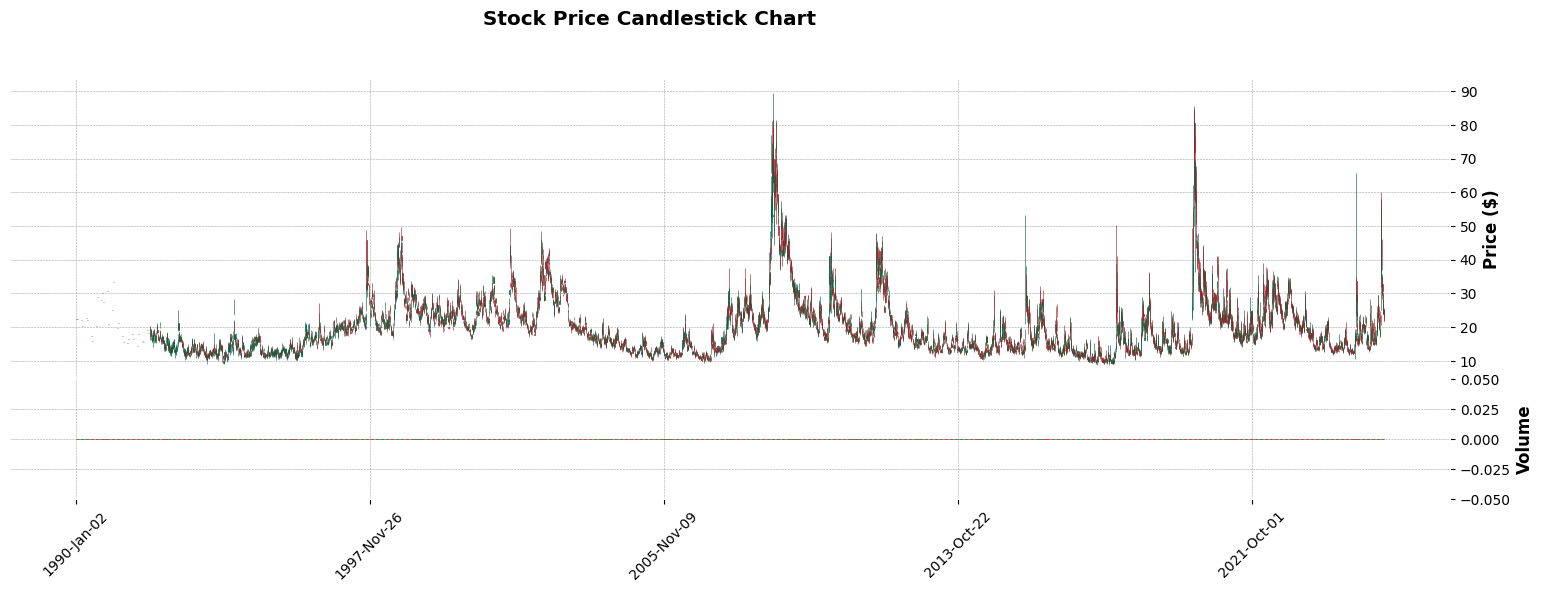

In [30]:
import pandas as pd
import mplfinance as mpf  # Please install mplfinance as follows: pip install mplfinance

# df = pd.read_csv("./data/^IXIC_history_2025-04-29.csv")
df = pd.read_csv("./data/^VIX_history_1d_2025-05-12.csv")

df['Date'] = pd.to_datetime(df['Date'], utc=True)

# Set 'Date' column as the index
df.set_index('Date', inplace=True)

# df = df.tail(365*1)

# Plot the candlestick chart
mpf.plot(df, type='candlestick', style='charles', title='Stock Price Candlestick Chart', ylabel='Price ($)', figsize=(20, 6), volume=True)
# mpf.plot(df, type='line', style='charles', title='Stock Price Line Chart', ylabel='Price ($)', figsize=(20, 6))
# mpf.plot(df, type='line', style='charles', title='Stock Price Line Chart', ylabel='Price ($)', figsize=(20, 6), volume=True)

In [45]:
import pandas as pd
import mplfinance as mpf
import os

def plot_ene_for_stocks(stock_configs):
    """
    根据传入的股票配置列表绘制ENE图表。

    参数：
        stock_configs (list of dict): 每个字典包含以下字段：
            - 'name': 股票名称（用于标题）
            - 'path': CSV 文件路径
            - 'N': 均线天数
            - 'M1': 上轨比例
            - 'M2': 下轨比例
            - 'years': 可视化年数（默认1）
    """
    for config in stock_configs:
        name = config.get('name', 'Unnamed')
        path = config['path']
        N = config['N']
        M1 = config['M1']
        M2 = config['M2']
        years = config.get('years', 1)

        if not os.path.exists(path):
            print(f"[错误] 找不到文件: {path}")
            continue

        df = pd.read_csv(path)
        df['Date'] = pd.to_datetime(df['Date'], utc=True)
        df.set_index('Date', inplace=True)

        # 留足均线计算天数
        df = df.tail(int(365 * years) + N)

        # 计算 ENE
        ma = df['Close'].rolling(window=N).mean()
        df['UPPER'] = ma * (1 + M1)
        df['LOWER'] = ma * (1 - M2)
        df['ENE'] = (df['UPPER'] + df['LOWER']) / 2

        # 保留可视化天数
        df = df.tail(int(365 * years))

        addplots = [
            mpf.make_addplot(df['UPPER'], color='green', linestyle='--', width=0.8),
            mpf.make_addplot(df['LOWER'], color='red', linestyle='--', width=0.8),
            mpf.make_addplot(df['ENE'], color='blue', linestyle='-', width=1)
        ]

        mpf.plot(df, type='line', style='charles', #type='line' is quiet, 'candle' is not
                 title=f"{name} ENE (N={N}, M1={M1*100:.0f}%, M2={M2*100:.0f}%)",
                 ylabel='Price', figsize=(20, 4),
                 addplot=addplots, volume=True)

# shut up the warnings...
import warnings
warnings.filterwarnings("ignore")

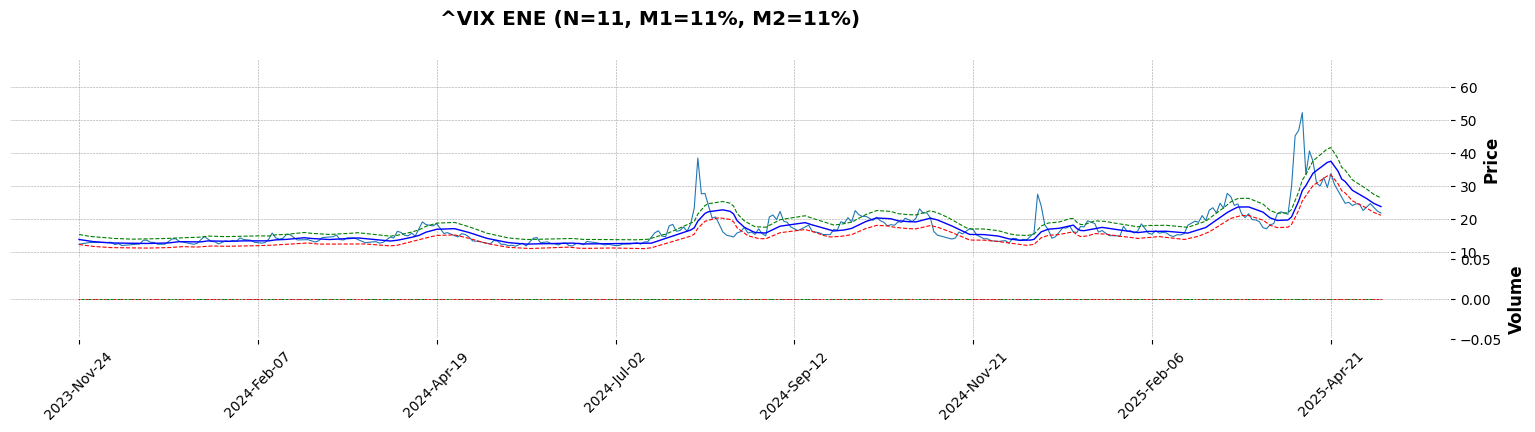

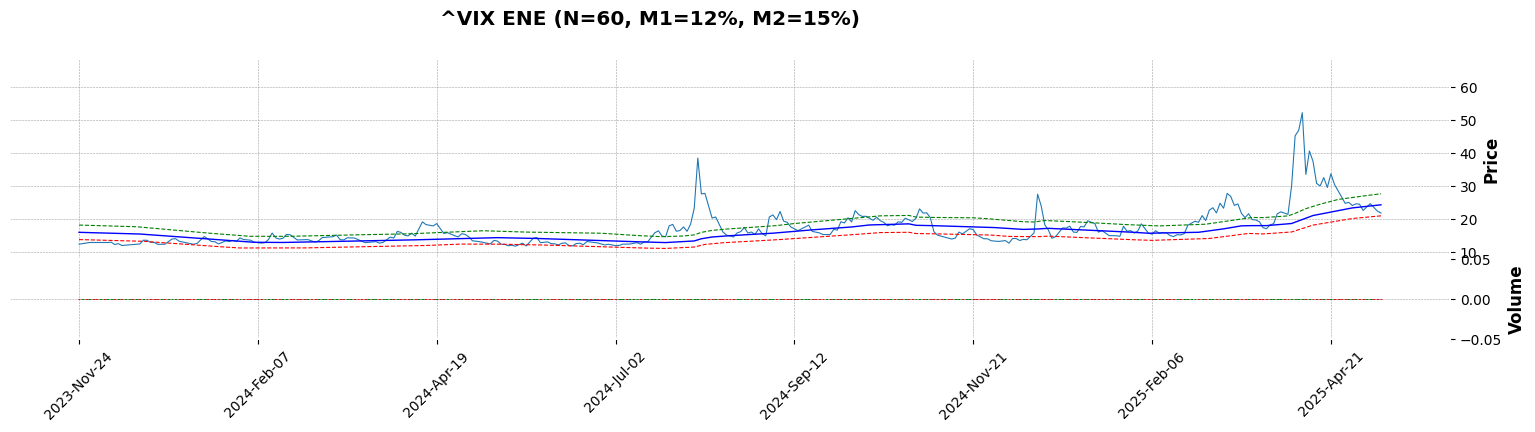

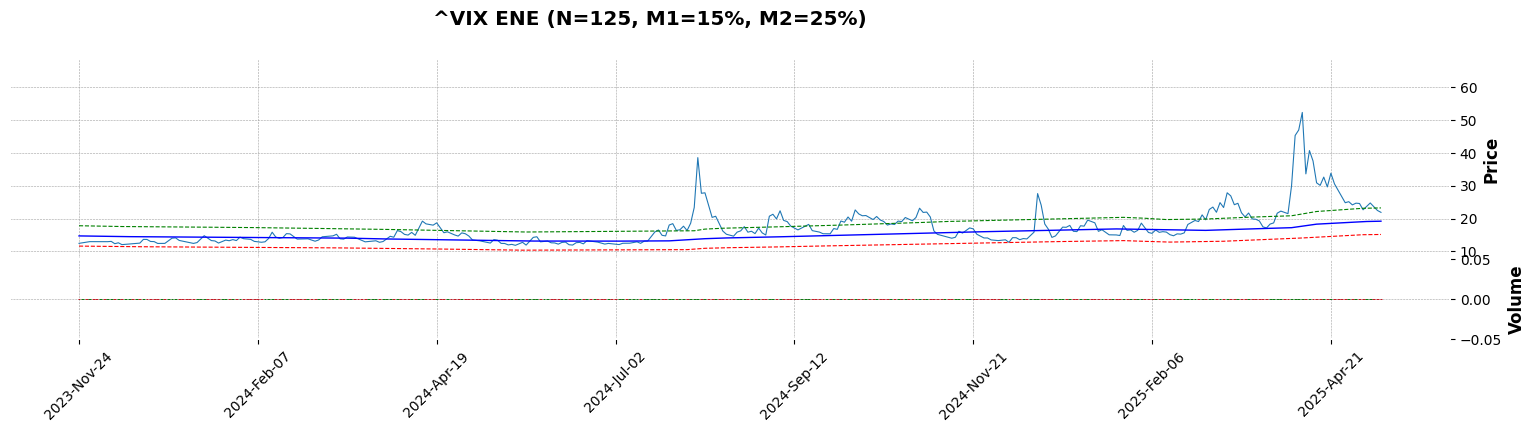

In [46]:
ticker_name = '^VIX'
data_date = '2025-05-12'
interval = '1d'
data_path = f'./data/{ticker_name}_history_{interval}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 1
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 60,
        'M1': 0.12,
        'M2': 0.15,
        'years': 1
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 1
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)


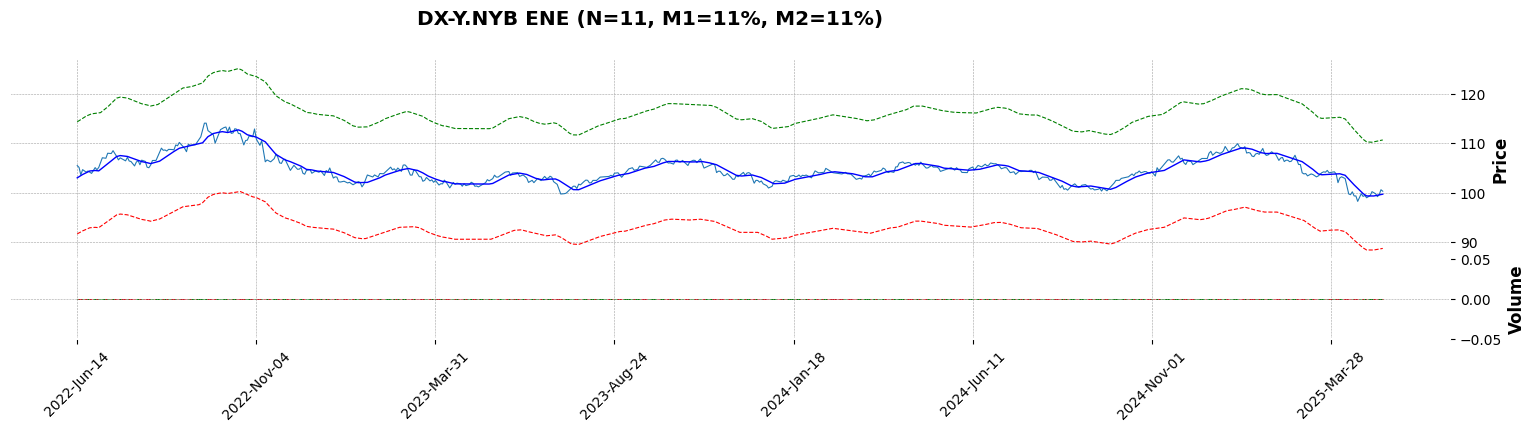

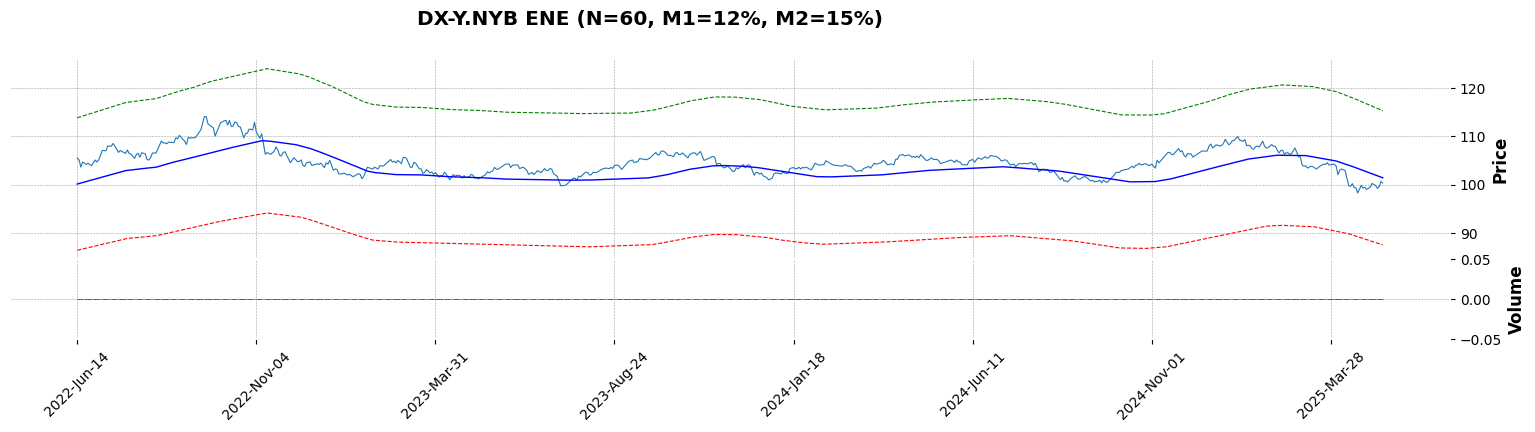

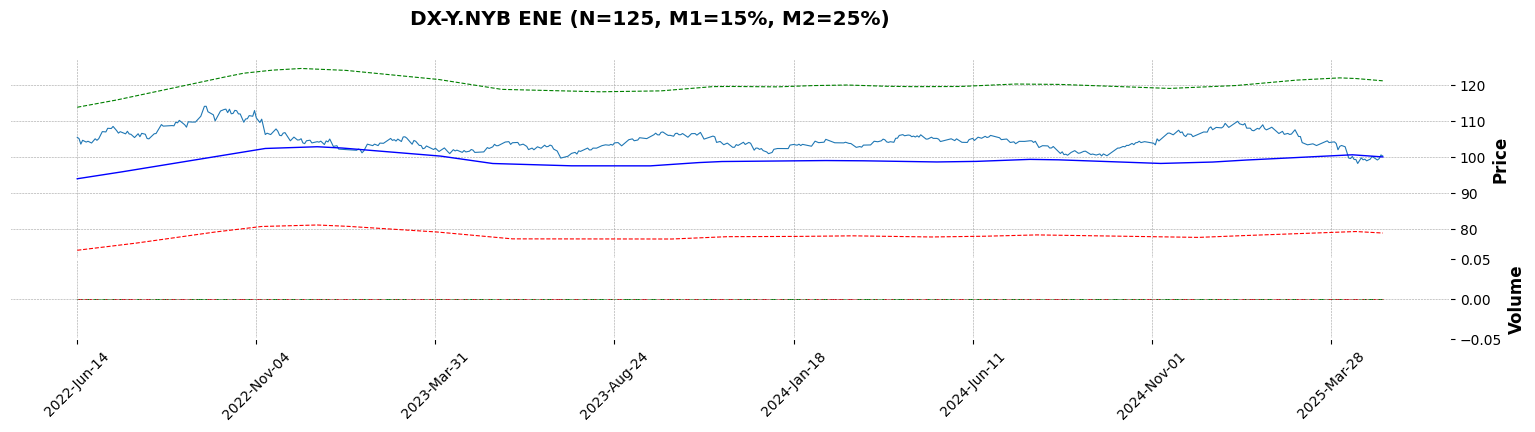

In [47]:
ticker_name = 'DX-Y.NYB'
data_date = '2025-05-12'
interval = '1d'
data_path = f'./data/{ticker_name}_history_{interval}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name,
        'path': data_path,
        'N': 11,
        'M1': 0.11,
        'M2': 0.11,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 60,
        'M1': 0.12,
        'M2': 0.15,
        'years': 2
    },
    {
        'name': ticker_name,
        'path': data_path,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 2
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)


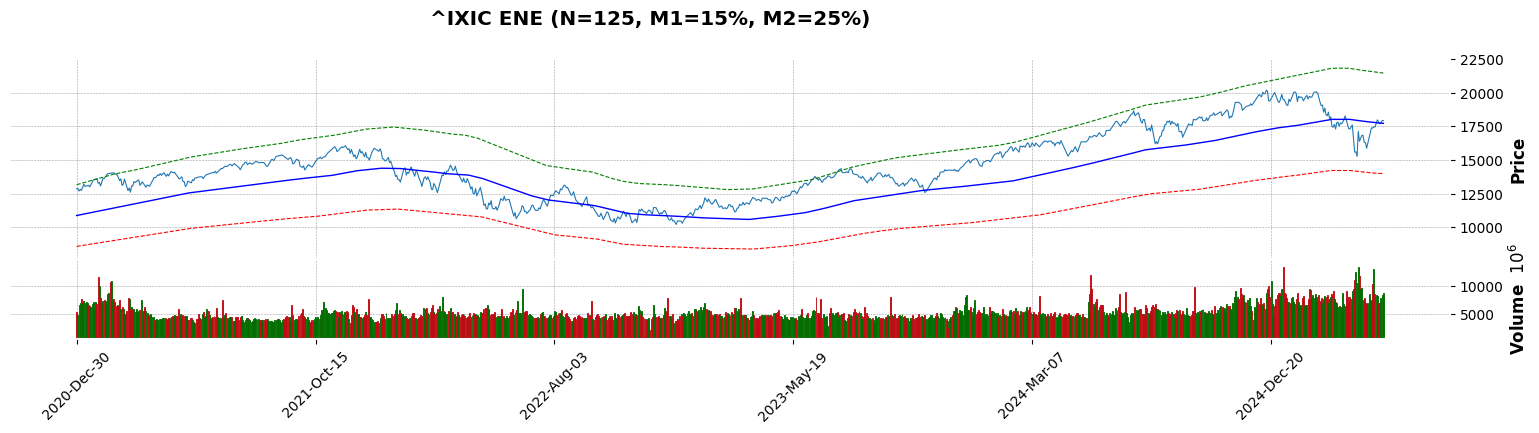

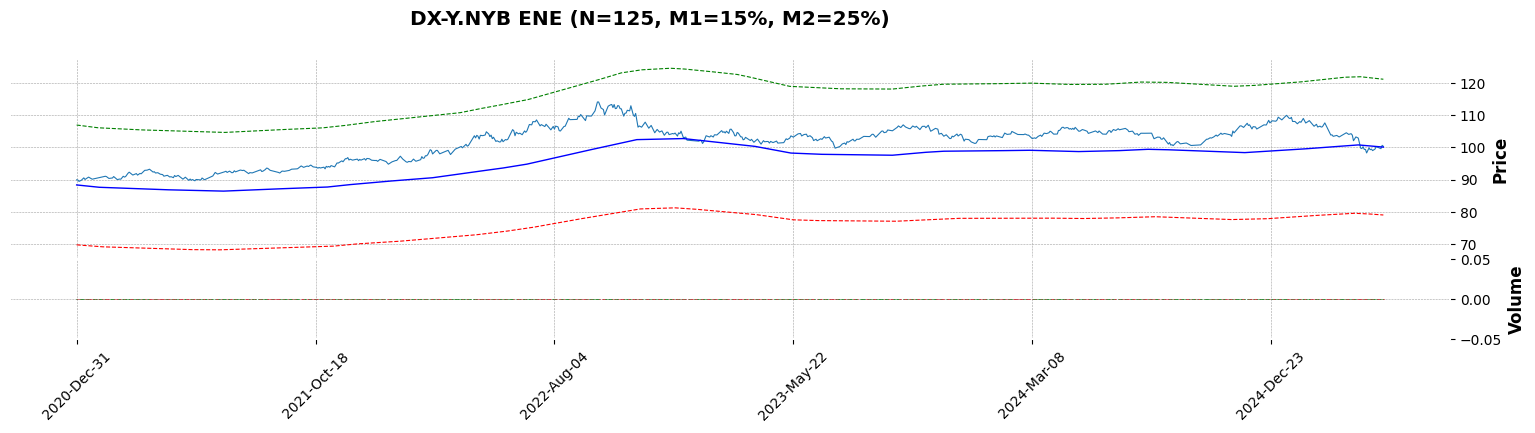

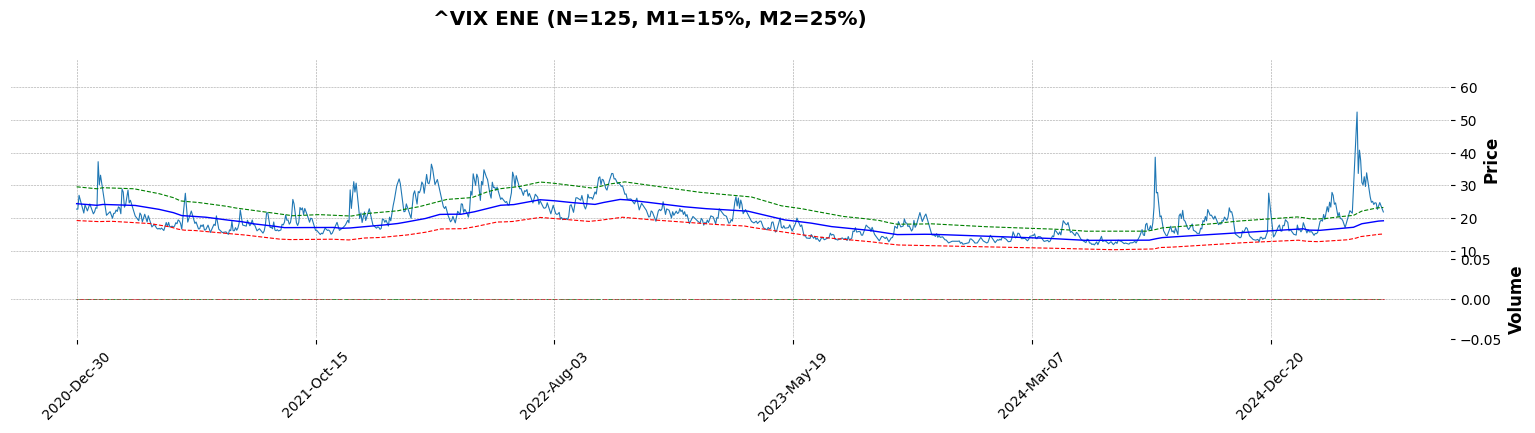

In [48]:
ticker_name1 = '^IXIC'
ticker_name2 = 'DX-Y.NYB'
ticker_name3 = '^VIX'
data_date = '2025-05-12'
interval = '1d'
data_path1 = f'./data/{ticker_name1}_history_{interval}_{data_date}.csv'
data_path2 = f'./data/{ticker_name2}_history_{interval}_{data_date}.csv'
data_path3 = f'./data/{ticker_name3}_history_{interval}_{data_date}.csv'
# 调用:
stock_configs = [
    {
        'name': ticker_name1,
        'path': data_path1,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 3
    },
    {
        'name': ticker_name2,
        'path': data_path2,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 3
    },
    {
        'name': ticker_name3,
        'path': data_path3,
        'N': 125,
        'M1': 0.15,
        'M2': 0.25,
        'years': 3
    }
]

# 运行:
plot_ene_for_stocks(stock_configs)
